# Assignment 6: Regression Models in Machine Learning

- Submitted by -- Sruthilaya Umasankari Soma Shanmuga Sundaram

**Datasets used:** Salary_Data.csv, 50_Startups.csv, Position_Salaries.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import scipy.stats as stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

-----
## Q1 : Linear Regression: Data Pipeline & Model

### Q1a - load_and_split()

In [2]:
def load_and_split(filepath, test_size=1/3, random_state=0):
    df = pd.read_csv(filepath)
    feature_col = df.columns[0]
    target_col  = df.columns[1]
    X = df[[feature_col]].values
    y = df[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"Feature column : {feature_col}")
    print(f"Target  column : {target_col}")
    print(f"X_train shape  : {X_train.shape}  |  y_train shape : {y_train.shape}")
    print(f"X_test  shape  : {X_test.shape}   |  y_test  shape : {y_test.shape}")
    print(f"\n{feature_col} mean: {df[feature_col].mean():.4f}, std: {df[feature_col].std():.4f}")
    print(f"{target_col} mean: {df[target_col].mean():.4f}, std: {df[target_col].std():.4f}")

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_and_split('data/Salary_Data.csv') #salary csv has 30 rows

Feature column : YearsExperience
Target  column : Salary
X_train shape  : (20, 1)  |  y_train shape : (20,)
X_test  shape  : (10, 1)   |  y_test  shape : (10,)

YearsExperience mean: 5.3133, std: 2.8379
Salary mean: 76003.0000, std: 27414.4298


### Q1b - train_and_evaluate()

In [3]:
def train_and_evaluate(X_train, X_test, y_train, y_test):
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)
    y_pred = regressor.predict(X_test)
    r2_train = regressor.score(X_train, y_train)
    r2_test  = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"Coefficient (slope) : {regressor.coef_[0]:.2f}")
    print(f"Intercept           : {regressor.intercept_:.2f}")
    print(f"R² (train)          : {r2_train:.2f}")
    print(f"R² (test)           : {r2_test:.2f}")
    print(f"MAE                 : {mae:.2f}")
    print(f"MSE                 : {mse:.2f}")
    print(f"RMSE                : {rmse:.2f}")

    return regressor

model = train_and_evaluate(X_train, X_test, y_train, y_test)

Coefficient (slope) : 9345.94
Intercept           : 26816.19
R² (train)          : 0.94
R² (test)           : 0.97
MAE                 : 3426.43
MSE                 : 21026037.33
RMSE                : 4585.42


### Q1c - plot_regression()

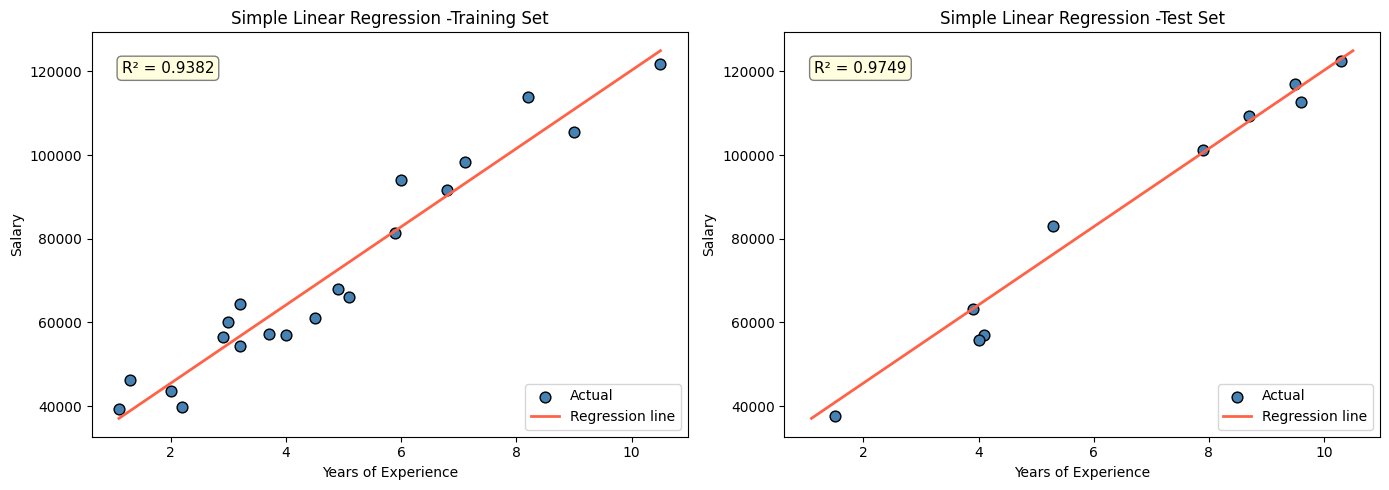

In [4]:
def plot_regression(X_train, y_train, X_test, y_test, model):
    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    x_line = np.linspace(
        min(X_train.min(), X_test.min()),
        max(X_train.max(), X_test.max()),
        200
    ).reshape(-1, 1)
    y_line = model.predict(x_line)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, X, y, title, r2 in [
        (axes[0], X_train, y_train, 'Training Set', r2_train),
        (axes[1], X_test,  y_test,  'Test Set',     r2_test)
    ]:
        ax.scatter(X, y, color='steelblue', label='Actual', edgecolors='k', s=60)
        ax.plot(x_line, y_line, color='tomato', linewidth=2, label='Regression line')
        ax.annotate(f'R² = {r2:.4f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
        ax.set_title(f'Simple Linear Regression -{title}')
        ax.set_xlabel('Years of Experience')
        ax.set_ylabel('Salary')
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_regression(X_train, y_train, X_test, y_test, model) #the models generalises well with (test R^2 is closer to train R^2)

-----
## Q2: Simple Linear Regression: Diagnostics & Robustness

### Q2a- plot_residuals

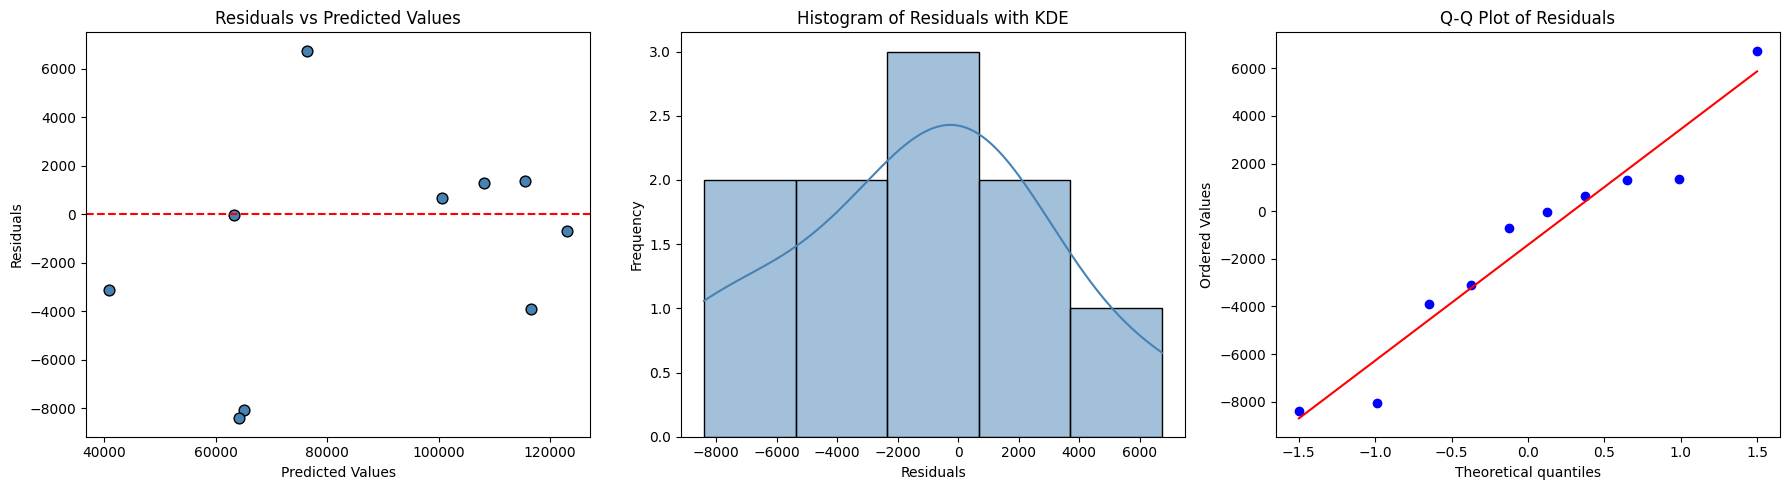

In [5]:
def plot_residuals(model, X_test, y_test):
    y_pred    = model.predict(X_test)
    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    #(i) Residuals vs Predicted
    axes[0].scatter(y_pred, residuals, color='steelblue', edgecolors='k', s=60)
    axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0].set_title('Residuals vs Predicted Values')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')

    #(ii) Histogram of residuals with KDE
    sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue', edgecolor='k')
    axes[1].set_title('Histogram of Residuals with KDE')
    axes[1].set_xlabel('Residuals')
    axes[1].set_ylabel('Frequency')

    #(iii) Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot of Residuals')

    plt.tight_layout()
    plt.show()

    # Discussion: The residuals points scatter around zero without a clear pattern indicating 
    # constant error variance and the histogram is approximately bell-shaped, 
    # and points in the Q-Q plot closely follow the diagonal line.
    # All the three support the assumptions of linear regression.
    # The model is appropriate for this dataset.

plot_residuals(model, X_test, y_test)

### Q2b - split_sensitivity()

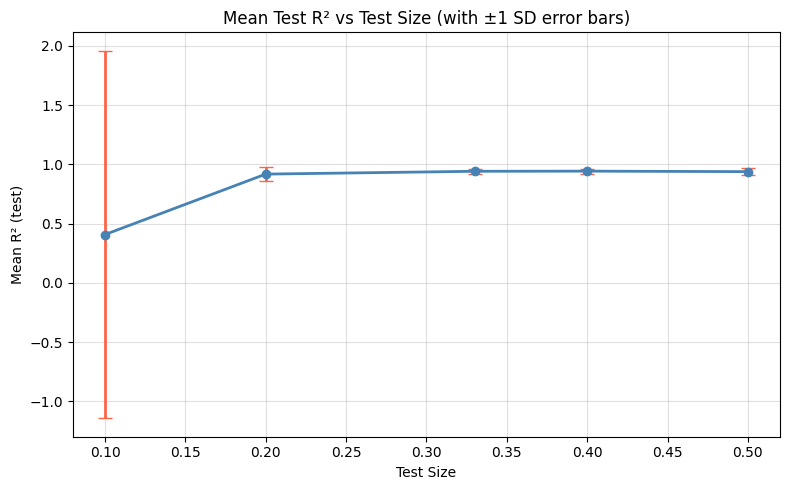

   test_size   mean_r2    std_r2
0       0.10  0.407903  1.550549
1       0.20  0.917609  0.061271
2       0.33  0.941332  0.022288
3       0.40  0.942597  0.020601
4       0.50  0.938406  0.029754


In [6]:
def split_sensitivity(filepath, test_sizes, n_repeats=20):
    records = []
    for ts in test_sizes:
        r2_scores = []
        for rs in range(n_repeats):
            Xtr, Xte, ytr, yte = load_and_split.__wrapped__(filepath, ts, rs) if hasattr(load_and_split, '__wrapped__') else _load_split_silent(filepath, ts, rs)
            m = LinearRegression().fit(Xtr, ytr)
            r2_scores.append(r2_score(yte, m.predict(Xte)))
        records.append({'test_size': ts, 'mean_r2': np.mean(r2_scores), 'std_r2': np.std(r2_scores)})

    df_results = pd.DataFrame(records)

    plt.figure(figsize=(8, 5))
    plt.errorbar(df_results['test_size'], df_results['mean_r2'],
                 yerr=df_results['std_r2'], fmt='o-', capsize=5,
                 color='steelblue', ecolor='tomato', linewidth=2)
    plt.title('Mean Test R² vs Test Size (with ±1 SD error bars)')
    plt.xlabel('Test Size')
    plt.ylabel('Mean R² (test)')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return df_results

def _load_split_silent(filepath, test_size, random_state):
    df = pd.read_csv(filepath)
    X = df[[df.columns[0]]].values
    y = df[df.columns[1]].values
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def split_sensitivity(filepath, test_sizes, n_repeats=20):
    records = []
    for ts in test_sizes:
        r2_scores = []
        for rs in range(n_repeats):
            Xtr, Xte, ytr, yte = _load_split_silent(filepath, ts, rs)
            m = LinearRegression().fit(Xtr, ytr)
            r2_scores.append(r2_score(yte, m.predict(Xte)))
        records.append({'test_size': ts, 'mean_r2': np.mean(r2_scores), 'std_r2': np.std(r2_scores)})

    df_results = pd.DataFrame(records)

    plt.figure(figsize=(8, 5))
    plt.errorbar(df_results['test_size'], df_results['mean_r2'],
                 yerr=df_results['std_r2'], fmt='o-', capsize=5,
                 color='steelblue', ecolor='tomato', linewidth=2)
    plt.title('Mean Test R² vs Test Size (with ±1 SD error bars)')
    plt.xlabel('Test Size')
    plt.ylabel('Mean R² (test)')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return df_results

sensitivity_df = split_sensitivity('data/Salary_Data.csv', [0.1, 0.2, 0.33, 0.4, 0.5])
print(sensitivity_df)

### Q2c - predict_salary()

In [7]:
def predict_salary(model, X_train, y_train, years_list):
    y_train_pred = model.predict(X_train)
    residuals    = y_train - y_train_pred
    n            = len(X_train)
    se           = np.std(residuals, ddof=2)
    x_mean       = X_train.mean()
    ss_x         = np.sum((X_train - x_mean) ** 2)
    t_val        = stats.t.ppf(0.975, df=n - 2)

    print(f"{'Years':>8} {'Predicted Salary':>18} {'Lower Bound (95%)':>20} {'Upper Bound (95%)':>20}")
    for yrs in years_list:
        x_new    = np.array([[yrs]])
        y_hat    = model.predict(x_new)[0]
        margin   = t_val * se * np.sqrt(1 + 1/n + (yrs - x_mean)**2 / ss_x)
        lb, ub   = y_hat - margin, y_hat + margin
        print(f"{yrs:>8.1f} {y_hat:>18,.2f} {lb:>20,.2f} {ub:>20,.2f}")

predict_salary(model, X_train, y_train, [1.5, 5.0, 10.0, 15.0, 20.0])

   Years   Predicted Salary    Lower Bound (95%)    Upper Bound (95%)
     1.5          40,835.11            26,534.86            55,135.35
     5.0          73,545.90            59,766.29            87,325.52
    10.0         120,275.62           105,144.01           135,407.23
    15.0         167,005.33           148,604.00           185,406.66
    20.0         213,735.04           190,957.68           236,512.40


-------
## Q3: Multiple Linear Regression: Full Pipeline

### Q3a- load_and_encode()

In [8]:
def load_and_encode(filepath, categorical_cols, target_col):
    df = pd.read_csv(filepath)
    feature_cols = [c for c in df.columns if c != target_col]
    X_raw = df[feature_cols]
    y     = df[target_col].values

    cat_indices = [feature_cols.index(c) for c in categorical_cols]

    ct = ColumnTransformer(
        transformers=[('encoder', OneHotEncoder(sparse_output=False, drop='first'), cat_indices)],
        remainder='passthrough'
    )
    X = np.array(ct.fit_transform(X_raw))

    ohe_feature_names = ct.named_transformers_['encoder'].get_feature_names_out(categorical_cols).tolist()
    passthrough_names = [feature_cols[i] for i in range(len(feature_cols)) if i not in cat_indices]
    encoded_col_names = ohe_feature_names + passthrough_names

    print("Encoded Feature Matrix:")
    print(pd.DataFrame(X, columns=encoded_col_names).head(10).to_string())

    return X, y, ct

X_mlr, y_mlr, ct_mlr = load_and_encode('data/50_Startups.csv', ['State'], 'Profit')

Encoded Feature Matrix:
   State_Florida  State_New York  R&D Spend  Administration  Marketing Spend
0            0.0             1.0  165349.20       136897.80        471784.10
1            0.0             0.0  162597.70       151377.59        443898.53
2            1.0             0.0  153441.51       101145.55        407934.54
3            0.0             1.0  144372.41       118671.85        383199.62
4            1.0             0.0  142107.34        91391.77        366168.42
5            0.0             1.0  131876.90        99814.71        362861.36
6            0.0             0.0  134615.46       147198.87        127716.82
7            1.0             0.0  130298.13       145530.06        323876.68
8            0.0             1.0  120542.52       148718.95        311613.29
9            0.0             0.0  123334.88       108679.17        304981.62


### Q3b- train_multiple_regression()

In [9]:
def train_multiple_regression(X, y, test_size=0.2, random_state=0):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=random_state)

    regressor = LinearRegression()
    regressor.fit(X_tr, y_tr)
    y_pred = regressor.predict(X_te)

    n_features = X.shape[1]
    feature_names = [f'Feature_{i}' for i in range(n_features)]

    print("Intercept:", round(regressor.intercept_, 4))
    print("\nCoefficients:")
    for name, coef in zip(feature_names, regressor.coef_):
        print(f"  {name:30s} : {coef:.4f}")

    print(f"\nR² (train) : {regressor.score(X_tr, y_tr):.4f}")
    print(f"R² (test)  : {r2_score(y_te, y_pred):.4f}")

    comparison = pd.DataFrame({
        'Actual'           : y_te,
        'Predicted'        : y_pred.round(2),
        'Error'            : (y_te - y_pred).round(2),
        'Percentage Error' : (np.abs((y_te - y_pred) / y_te) * 100).round(2)
    })
    print("\nPredicted vs Actual (test set):")
    print(comparison.to_string(index=False))

    return regressor, X_te, y_te, y_pred

model_mlr, X_te_mlr, y_te_mlr, y_pred_mlr = train_multiple_regression(X_mlr, y_mlr)

Intercept: 42554.1676

Coefficients:
  Feature_0                      : -959.2842
  Feature_1                      : 699.3691
  Feature_2                      : 0.7735
  Feature_3                      : 0.0329
  Feature_4                      : 0.0366

R² (train) : 0.9502
R² (test)  : 0.9347

Predicted vs Actual (test set):
   Actual  Predicted     Error  Percentage Error
103282.38  103015.20    267.18              0.26
144259.40  132582.28  11677.12              8.09
146121.95  132447.74  13674.21              9.36
 77798.83   71976.10   5822.73              7.48
191050.39  178537.48  12512.91              6.55
105008.31  116161.24 -11152.93             10.62
 81229.06   67851.69  13377.37             16.47
 97483.56   98791.73  -1308.17              1.34
110352.25  113969.44  -3617.19              3.28
166187.94  167921.07  -1733.13              1.04


In [10]:
df_50 = pd.read_csv('data/50_Startups.csv')
feature_cols_50 = [c for c in df_50.columns if c != 'Profit']
cat_indices_50  = [feature_cols_50.index('State')]

ohe_names = ct_mlr.named_transformers_['encoder'].get_feature_names_out(['State']).tolist()
pass_names = [feature_cols_50[i] for i in range(len(feature_cols_50)) if i not in cat_indices_50]
encoded_feature_names = ohe_names + pass_names

def train_multiple_regression_named(X, y, feature_names, test_size=0.2, random_state=0):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=random_state)

    regressor = LinearRegression()
    regressor.fit(X_tr, y_tr)
    y_pred = regressor.predict(X_te)

    print("Intercept:", round(regressor.intercept_, 4))
    print("\nCoefficients:")
    for name, coef in zip(feature_names, regressor.coef_):
        print(f"  {name:30s} : {coef:.4f}")

    print(f"\nR² (train) : {regressor.score(X_tr, y_tr):.4f}")
    print(f"R² (test)  : {r2_score(y_te, y_pred):.4f}")

    comparison = pd.DataFrame({
        'Actual'           : y_te.round(2),
        'Predicted'        : y_pred.round(2),
        'Error'            : (y_te - y_pred).round(2),
        'Percentage Error' : (np.abs((y_te - y_pred) / y_te) * 100).round(2)
    })
    print("\nPredicted vs Actual (test set):")
    print(comparison.to_string(index=False))

    return regressor, X_te, y_te, y_pred

model_mlr, X_te_mlr, y_te_mlr, y_pred_mlr = train_multiple_regression_named(
    X_mlr, y_mlr, encoded_feature_names
)

Intercept: 42554.1676

Coefficients:
  State_Florida                  : -959.2842
  State_New York                 : 699.3691
  R&D Spend                      : 0.7735
  Administration                 : 0.0329
  Marketing Spend                : 0.0366

R² (train) : 0.9502
R² (test)  : 0.9347

Predicted vs Actual (test set):
   Actual  Predicted     Error  Percentage Error
103282.38  103015.20    267.18              0.26
144259.40  132582.28  11677.12              8.09
146121.95  132447.74  13674.21              9.36
 77798.83   71976.10   5822.73              7.48
191050.39  178537.48  12512.91              6.55
105008.31  116161.24 -11152.93             10.62
 81229.06   67851.69  13377.37             16.47
 97483.56   98791.73  -1308.17              1.34
110352.25  113969.44  -3617.19              3.28
166187.94  167921.07  -1733.13              1.04


### Q3c- feature_importance_chart

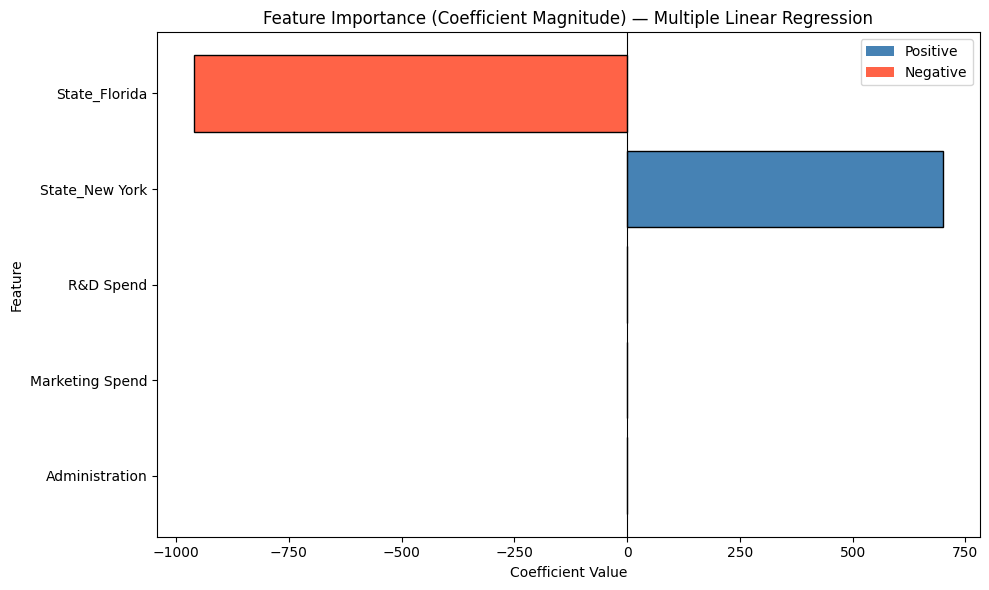

In [11]:
def feature_importance_chart(model, feature_names):
    coefs = model.coef_
    sorted_idx = np.argsort(np.abs(coefs))
    sorted_coefs = coefs[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]
    colors = ['tomato' if c < 0 else 'steelblue' for c in sorted_coefs]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(sorted_names, sorted_coefs, color=colors, edgecolor='k')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Feature Importance (Coefficient Magnitude) — Multiple Linear Regression')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', label='Positive'), Patch(facecolor='tomato', label='Negative')]
    plt.legend(handles=legend_elements)
    plt.tight_layout()
    plt.show()

    # R&D Spend and Marketing Spend dominate. They have the largest coefficients by far.
    # Adminstration has a samll negative coeff. The state dummy variable has very small coeff
    # which states a startup barely matters once you account for how they spend their money
    # State dummies do not contribute meaningful to predict Profit.

feature_importance_chart(model_mlr, encoded_feature_names)

-------
## Q4: Multiple Linear Regression: Feature Selection & Validation

### Q4a- backward_elimination

In [12]:
def backward_elimination(X, y, feature_names, significance_level=0.05):
    remaining = list(range(X.shape[1]))
    remaining_names = list(feature_names)

    while True:
        X_sel = sm.add_constant(X[:, remaining])
        ols   = sm.OLS(y, X_sel).fit()
        p_values = ols.pvalues[1:]
        max_p    = p_values.max()

        if max_p > significance_level:
            worst_local_idx = p_values.argmax()
            removed_name    = remaining_names[worst_local_idx]
            print(f"Removing '{removed_name}' with p-value = {max_p:.4f}")
            remaining.pop(worst_local_idx)
            remaining_names.pop(worst_local_idx)
        else:
            break

    print(f"\nSelected features: {remaining_names}")
    print(ols.summary())

    X_selected = X[:, remaining]
    X_tr, X_te, y_tr, y_te = train_test_split(X_selected, y, test_size=0.2, random_state=0)
    lr_selected = LinearRegression().fit(X_tr, y_tr)
    r2_selected = r2_score(y_te, lr_selected.predict(X_te))
    X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X, y, test_size=0.2, random_state=0)
    r2_full = r2_score(y_te_f, LinearRegression().fit(X_tr_f, y_tr_f).predict(X_te_f))

    print(f"\nR² (selected features) : {r2_selected:.2f}")
    print(f"R² (full model Q3)     : {r2_full:.2f}")

    return remaining_names, ols

selected_features, ols_summary = backward_elimination(X_mlr, y_mlr, encoded_feature_names)

Removing 'State_New York' with p-value = 0.9898
Removing 'State_Florida' with p-value = 0.9398
Removing 'Administration' with p-value = 0.6018
Removing 'Marketing Spend' with p-value = 0.0600

Selected features: ['R&D Spend']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           3.50e-32
Time:                        01:05:27   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                          

### Q4b- cross_validate_model

k= 3 — Mean R²: 0.6526 ± 0.1157
k= 5 — Mean R²: -0.2551 ± 0.7504
k=10 — Mean R²: -4.5125 ± 5.1833


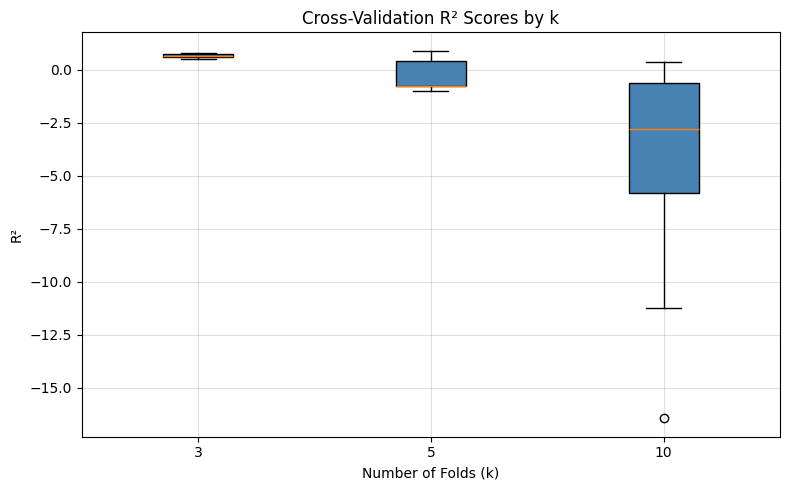

    k   mean_r2    std_r2
0   3  0.652556  0.115710
1   5 -0.255140  0.750409
2  10 -4.512548  5.183325


In [13]:
def cross_validate_model(X, y, cv_folds=[3, 5, 10]):
    records = []
    all_scores = {}

    for k in cv_folds:
        scores = cross_val_score(LinearRegression(), X, y, cv=k, scoring='r2')
        all_scores[str(k)] = scores
        print(f"k={k:>2} — Mean R²: {scores.mean():.4f} ± {scores.std():.4f}")
        records.append({'k': k, 'mean_r2': scores.mean(), 'std_r2': scores.std()})

    # Box plot
    plt.figure(figsize=(8, 5))
    plt.boxplot(all_scores.values(), labels=[str(k) for k in cv_folds], patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='k'))
    plt.title('Cross-Validation R² Scores by k')
    plt.xlabel('Number of Folds (k)')
    plt.ylabel('R²')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(records)

cv_df = cross_validate_model(X_mlr, y_mlr)
print(cv_df)

### Q4c- predict_startup_profit

In [14]:
def predict_startup_profit(model, ct, new_data):
    try:
        X_new = np.array(ct.transform(new_data))
        predictions = model.predict(X_new)
        result = new_data.copy()
        result['Predicted Profit'] = predictions.round(2)
        print(result.to_string(index=False))
    except Exception as e:
        print(f"Encoding error (possibly unknown State): {e}")
        print("Attempting to predict with known features only...")

# Creating 3 synthetic startup records (same columns as 50_Startups.csv features, excluding Profit)
new_startups = pd.DataFrame({
    'R&D Spend'       : [150000, 80000, 30000],
    'Administration'  : [120000, 95000, 60000],
    'Marketing Spend' : [300000, 150000, 50000],
    'State'           : ['New York', 'California', 'Florida']
})

predict_startup_profit(model_mlr, ct_mlr, new_startups)

 R&D Spend  Administration  Marketing Spend      State  Predicted Profit
    150000          120000           300000   New York         174202.78
     80000           95000           150000 California         113047.08
     30000           60000            50000    Florida          68602.48


------------------
## Q5: Polynomial Regression: Degree Selection & Overfitting

In [15]:
df_pos = pd.read_csv('data/Position_Salaries.csv')
print(df_pos)
X_poly_raw = df_pos.iloc[:, 1].values.reshape(-1, 1)
y_poly_raw = df_pos.iloc[:, 2].values

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


### Q5a- fit_polynomial()

In [16]:
def fit_polynomial(X, y, degree):
    poly_reg = PolynomialFeatures(degree=degree)
    X_poly   = poly_reg.fit_transform(X)
    lin_reg  = LinearRegression()
    lin_reg.fit(X_poly, y)
    r2 = r2_score(y, lin_reg.predict(X_poly))
    return lin_reg, poly_reg, r2

m4, p4, r2_4 = fit_polynomial(X_poly_raw, y_poly_raw, degree=4)
print(f"Degree 4 R²: {r2_4:.4f}")

Degree 4 R²: 0.9974


### Q5b- find_best_degree()

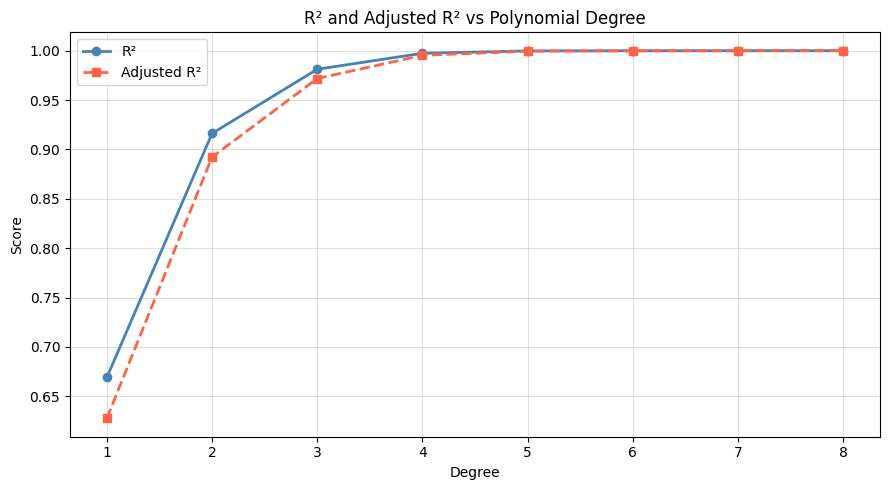

Best degree by Adjusted R²: 8


In [17]:
def find_best_degree(X, y, max_degree=8):
    n = len(y)
    degrees, r2_list, adj_r2_list = [], [], []

    for d in range(1, max_degree + 1):
        _, poly_tf, r2 = fit_polynomial(X, y, d)
        p = poly_tf.fit_transform(X).shape[1] - 1
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if (n - p - 1) > 0 else np.nan
        degrees.append(d)
        r2_list.append(r2)
        adj_r2_list.append(adj_r2)

    plt.figure(figsize=(9, 5))
    plt.plot(degrees, r2_list,     'o-', label='R²',          color='steelblue', linewidth=2)
    plt.plot(degrees, adj_r2_list, 's--', label='Adjusted R²', color='tomato',    linewidth=2)
    plt.title('R² and Adjusted R² vs Polynomial Degree')
    plt.xlabel('Degree')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    best_degree = degrees[np.nanargmax(adj_r2_list)]
    print(f"Best degree by Adjusted R²: {best_degree}")

    # Because R² only measures how well the model fits the training data, it has no idea
    # if the model will work on new data. R² always increases as more polynomial terrms are added. 
    # It rewards complexity with penalizing it. Adjusted R² penalises extra complexity, 
    # it goes up if the new term improves the fit. 
    # So picking the degree where adjusted R² peask is the best balance of fit.
    # A high R² can mean a great model or a completely overfit one, 
    # and R² alone can't tell the difference.

    return best_degree

best_deg = find_best_degree(X_poly_raw, y_poly_raw)

### Q5c- plot_all_fits()

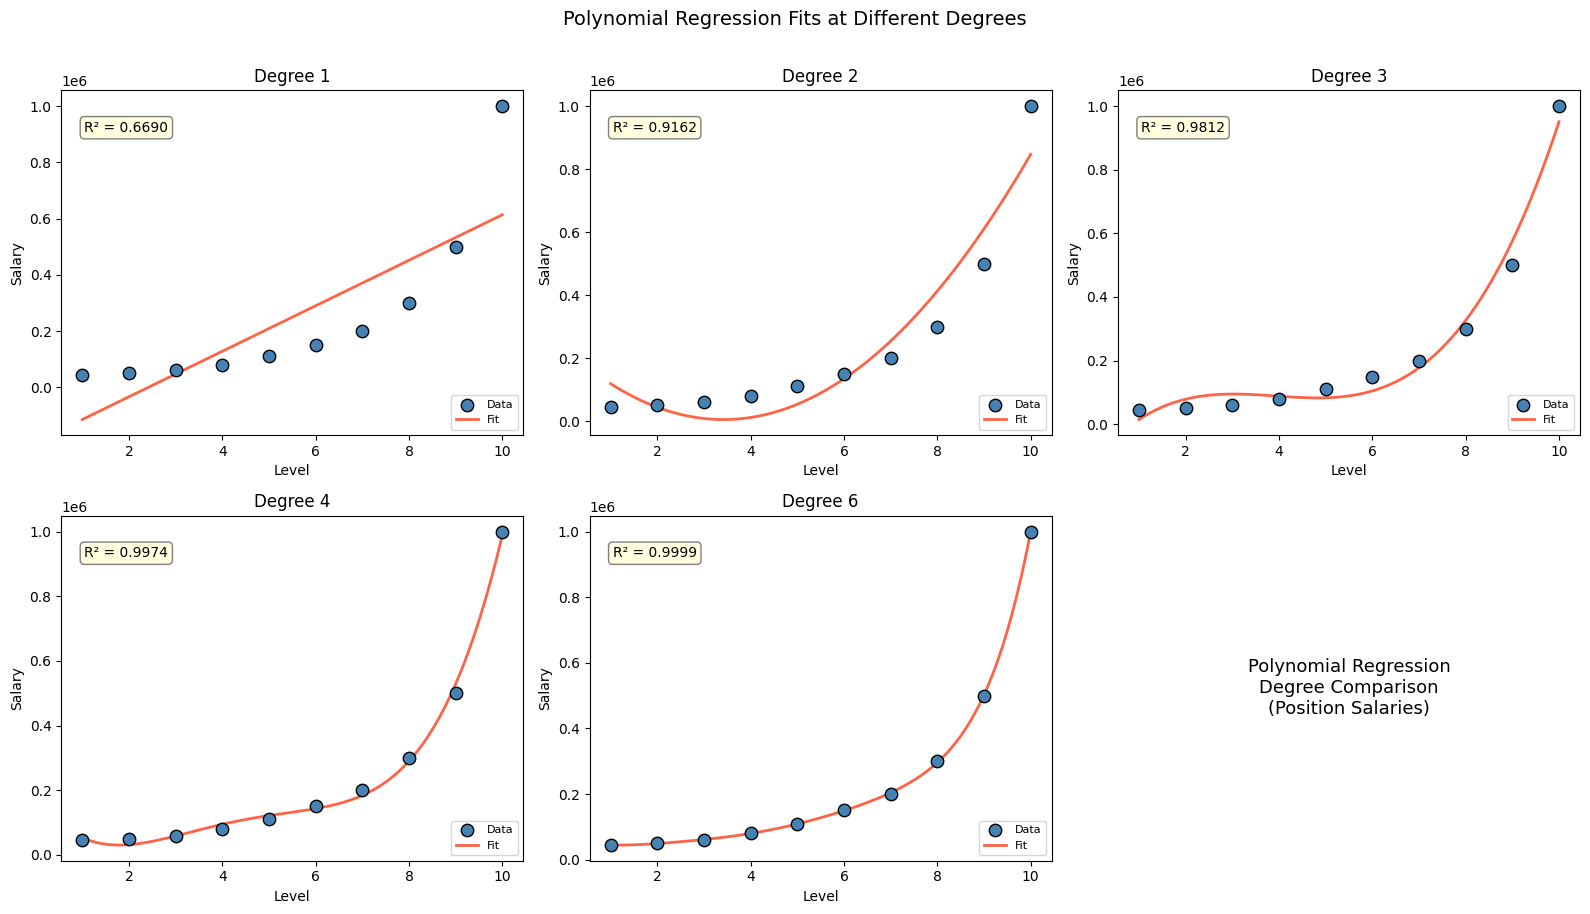

In [18]:
def plot_all_fits(X, y, degrees=[1, 2, 3, 4, 6]):
    X_grid = np.arange(X.min(), X.max() + 0.1, 0.1).reshape(-1, 1)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes_flat = axes.flatten()

    for i, deg in enumerate(degrees):
        model_d, poly_d, r2_d = fit_polynomial(X, y, deg)
        y_grid = model_d.predict(poly_d.transform(X_grid))

        ax = axes_flat[i]
        ax.scatter(X, y, color='steelblue', edgecolors='k', s=80, zorder=5, label='Data')
        ax.plot(X_grid, y_grid, color='tomato', linewidth=2, label='Fit')
        ax.set_title(f'Degree {deg}')
        ax.set_xlabel('Level')
        ax.set_ylabel('Salary')
        ax.annotate(f'R² = {r2_d:.4f}', xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
        ax.legend(fontsize=8)

    axes_flat[5].axis('off')
    axes_flat[5].text(0.5, 0.5,
        'Polynomial Regression\nDegree Comparison\n(Position Salaries)',
        ha='center', va='center', fontsize=13, transform=axes_flat[5].transAxes)

    plt.suptitle('Polynomial Regression Fits at Different Degrees', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Overfitting starts around degree 5-6. The curve begins wildly zigzagging
# between data points just to touch each one perfectly, it memorizes the
# training data instead of learning the pattern, so it would fail badly on new data.

plot_all_fits(X_poly_raw, y_poly_raw)